# ** Regresyon **

Basit Regresyon ve Çoklu Doğrusal Regresyon

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn .model_selection  import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression


plt.rcParams['figure.figsize']= [12,8]
plt.rcParams['font.size']= 12
sns.set_style('whitegrid')

In [ ]:
data=pd.read_excel('/content/Superlig_Proje.xlsx')
data.head()
df=data.copy()
df.head()

,Takim_Adi,Topa_Sahip_Olma,Isabetli_Pas_Sayisi,Pas_Isabeti_Yuzde,Isabetli_Uzun_Top,Isabetli_Orta,Sut_Sayisi,Isabetli_Sut,xG_Gol_Beklentisi,Buyuk_Sans_Yaratma,Korner_Sayisi,Basarili_Dripling,Rakip_Ceza_Sahasi_Dokunus,Top_Calma,Pas_Arasi,Uzaklastirma,Hucum_Bolgesi_Top_Calma,Zeminde_Kazanilan_Mucadele,Hava_Kazanilan_Mucadele,Atilan_Gol,Yenilen_Gol
0,Alanyaspor,48.5,337,83.2,17.1,4.8,206,67,19.0,2.2,4.7,6.5,13.411765,12.2,7.8,21.4,2.9,33.8,11.6,16,15
1,Antalyaspor,43.6,279,79.6,18.8,3.3,142,59,13.0,1.2,3.9,6.1,21.235294,15.8,7.0,29.4,2.4,35.5,12.8,16,31
2,Başakşehir,55.3,370,84.4,19.6,4.6,220,73,23.5,2.1,5.3,8.5,22.823529,14.7,7.6,20.4,4.3,36.2,15.2,25,18
3,Beşiktaş,52.5,337,81.9,15.9,5.1,261,100,33.5,3.6,5.1,7.3,26.352941,16.0,9.1,25.1,3.5,33.6,16.6,29,22
4,Eyüpspor,50.9,320,81.9,17.6,4.3,196,65,20.6,2.2,4.2,7.3,19.235294,15.8,8.2,22.1,3.8,37.6,11.1,10,24


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Takim_Adi                   18 non-null     object 
 1   Topa_Sahip_Olma             18 non-null     float64
 2   Isabetli_Pas_Sayisi         18 non-null     object 
 3   Pas_Isabeti_Yuzde           18 non-null     float64
 4   Isabetli_Uzun_Top           18 non-null     object 
 5   Isabetli_Orta               18 non-null     float64
 6   Sut_Sayisi                  18 non-null     int64  
 7   Isabetli_Sut                18 non-null     int64  
 8   xG_Gol_Beklentisi           18 non-null     float64
 9   Buyuk_Sans_Yaratma          18 non-null     float64
 10  Korner_Sayisi               18 non-null     float64
 11  Basarili_Dripling           18 non-null     float64
 12  Rakip_Ceza_Sahasi_Dokunus   18 non-null     float64
 13  Top_Calma                   18 non-nu

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Topa_Sahip_Olma,18.0,50.077778,5.979923,38.500000,47.700000,50.400000,53.175,62.100000
Pas_Isabeti_Yuzde,18.0,81.150000,4.181788,68.700000,79.600000,81.750000,83.275,87.300000
Isabetli_Orta,18.0,4.516667,1.061215,2.800000,3.600000,4.600000,5.100,6.900000
Sut_Sayisi,18.0,220.833333,45.287643,142.000000,187.750000,214.000000,243.750,315.000000
Isabetli_Sut,18.0,73.055556,20.380129,45.000000,60.250000,67.500000,77.250,116.000000
xG_Gol_Beklentisi,18.0,22.627778,6.979534,13.000000,18.025000,21.000000,25.450,36.700000
Buyuk_Sans_Yaratma,18.0,2.227778,0.702772,1.200000,1.800000,2.150000,2.550,3.600000
Korner_Sayisi,18.0,4.744444,0.745356,3.500000,4.250000,4.700000,5.175,6.300000
Basarili_Dripling,18.0,7.144444,1.343928,5.000000,6.125000,7.100000,8.350,9.800000
Rakip_Ceza_Sahasi_Dokunus,18.0,21.098039,4.597763,13.411765,18.058824,20.882353,23.000,31.764706


### *Veri Temizliği*

In [ ]:
for col in df.columns:
  if df[col].dtype=='object'and col !='Takim_Adi':
    df[col]=df[col].astype(str).str.replace('\xa0','',regex=False)
    df[col]=pd.to_numeric(df[col],errors='coerce')
df.head()

,Takim_Adi,Topa_Sahip_Olma,Isabetli_Pas_Sayisi,Pas_Isabeti_Yuzde,Isabetli_Uzun_Top,Isabetli_Orta,Sut_Sayisi,Isabetli_Sut,xG_Gol_Beklentisi,Buyuk_Sans_Yaratma,Korner_Sayisi,Basarili_Dripling,Rakip_Ceza_Sahasi_Dokunus,Top_Calma,Pas_Arasi,Uzaklastirma,Hucum_Bolgesi_Top_Calma,Zeminde_Kazanilan_Mucadele,Hava_Kazanilan_Mucadele,Atilan_Gol,Yenilen_Gol
0,Alanyaspor,48.5,337,83.2,17.1,4.8,206,67,19.0,2.2,4.7,6.5,13.411765,12.2,7.8,21.4,2.9,33.8,11.6,16,15
1,Antalyaspor,43.6,279,79.6,18.8,3.3,142,59,13.0,1.2,3.9,6.1,21.235294,15.8,7.0,29.4,2.4,35.5,12.8,16,31
2,Başakşehir,55.3,370,84.4,19.6,4.6,220,73,23.5,2.1,5.3,8.5,22.823529,14.7,7.6,20.4,4.3,36.2,15.2,25,18
3,Beşiktaş,52.5,337,81.9,15.9,5.1,261,100,33.5,3.6,5.1,7.3,26.352941,16.0,9.1,25.1,3.5,33.6,16.6,29,22
4,Eyüpspor,50.9,320,81.9,17.6,4.3,196,65,20.6,2.2,4.2,7.3,19.235294,15.8,8.2,22.1,3.8,37.6,11.1,10,24


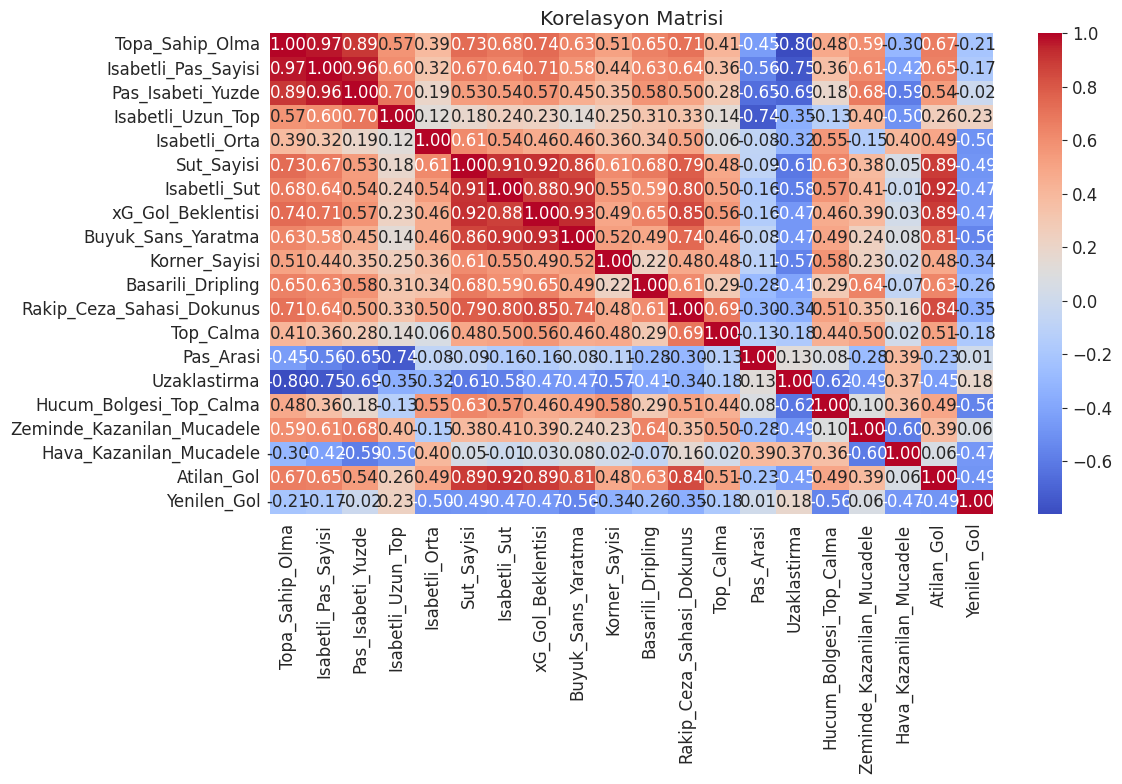

In [ ]:
# Keşifci Veri Analizi
# Korelasyon Matrisi
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True,fmt='.2f')
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [ ]:
target= 'Atilan_Gol'
corr_with_target = corr[target].sort_values(ascending=False)
print('Atilan Gol ile Korelasyonu:')
print(corr_with_target)
print('n yüksek 5 öznitelik:')
print(corr_with_target.head(6)[1:])#corr_with_target.iloc[1:6]


Atilan Gol ile Korelasyonu:
Atilan_Gol                    1.000000
Isabetli_Sut                  0.918211
Sut_Sayisi                    0.894282
xG_Gol_Beklentisi             0.891104
Rakip_Ceza_Sahasi_Dokunus     0.842530
Buyuk_Sans_Yaratma            0.811414
Topa_Sahip_Olma               0.669165
Isabetli_Pas_Sayisi           0.649931
Basarili_Dripling             0.630600
Pas_Isabeti_Yuzde             0.540165
Top_Calma                     0.512147
Hucum_Bolgesi_Top_Calma       0.490801
Isabetli_Orta                 0.488597
Korner_Sayisi                 0.480172
Zeminde_Kazanilan_Mucadele    0.385895
Isabetli_Uzun_Top             0.258785
Hava_Kazanilan_Mucadele       0.061761
Pas_Arasi                    -0.230798
Uzaklastirma                 -0.447077
Yenilen_Gol                  -0.487152
Name: Atilan_Gol, dtype: float64
n yüksek 5 öznitelik:
Isabetli_Sut                 0.918211
Sut_Sayisi                   0.894282
xG_Gol_Beklentisi            0.891104
Rakip_Ceza_Sahasi_Dokun

# Basit Regresyon

In [ ]:
x = df[['Isabetli_Sut']].values
y=df['Atilan_Gol'].values
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model_simple =LinearRegression()
model_simple.fit(x_train,y_train)

y_pred_train=model_simple.predict(x_train)
y_pre_test=model_simple.predict(x_test)

#model parametreleri

beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

print(f'Keşisim noktası:{beta_0:.3f}')
print(f'Eğim:{beta_1:.3f}')
print(f'Model Denklemi:')
print(f'Atilan_Gol= {beta_0:.3f}+{beta_1:.3f}*ısabetli_Sut')

Keşisim noktası:-6.206
Eğim:0.378
Model Denklemi:
Atilan_Gol= -6.206+0.378*ısabetli_Sut


In [ ]:
results= pd.DataFrame({'Gerçek Gol':y_test,
                       'Tahmin edilen Gol':y_pre_test,
                       'Fark':y_test-y_pre_test})

results.index=df.iloc[x_test.flatten().argsort()[:len(y_test)]]['Takim_Adi'].values if len(y_test) <= 5 else None
print('Test Seti Tahminleri')
print(results)

Test Seti Tahminleri
             Gerçek Gol  Tahmin edilen Gol      Fark
Beşiktaş             16          19.100633 -3.100633
Antalyaspor          16          16.078974 -0.078974
Alanyaspor           24          23.255415  0.744585
Başakşehir           13          11.546485  1.453515


In [ ]:
from operator import index
#Model perfonmans mertikleri
rmse_train=np.sqrt(mean_squared_error(y_train,y_pred_train))
rmse_test=np.sqrt(mean_squared_error(y_test,y_pre_test))
mae_train=mean_absolute_error(y_train,y_pred_train)
mae_test=mean_absolute_error(y_test,y_pre_test)
r2_train=r2_score(y_train,y_pred_train)
r2_test=r2_score(y_test,y_pre_test)


metrics=pd.DataFrame({
    'Veri Seti':['Eğitim','Test'],
    'RMSE':[rmse_train,rmse_test],
    'MAE':[mae_train,mae_test],
    'R2':[r2_train,r2_test]
})
print('Model Performans Metrikleri')
print(metrics.to_string(index=False))

Model Performans Metrikleri
Veri Seti     RMSE      MAE       R2
   Eğitim 3.517682 2.776432 0.831727
     Test 1.752661 1.344427 0.815921


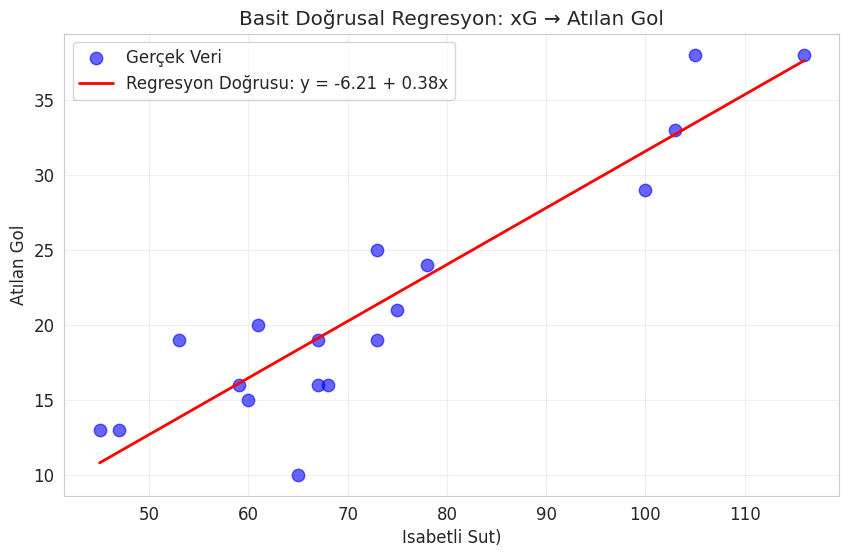

In [ ]:
# Görselleştirme: Regresyon doğrusu
plt.figure(figsize=(10, 6))

# Tüm veri noktaları
plt.scatter(x, y, color='blue', alpha=0.6, label='Gerçek Veri', s=80)

# Regresyon doğrusu (x sıralı)
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresyon Doğrusu: y = {beta_0:.2f} + {beta_1:.2f}x')

plt.xlabel('Isabetli Sut)')
plt.ylabel('Atılan Gol')
plt.title('Basit Doğrusal Regresyon: xG → Atılan Gol')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:



# Seçilen özellikler (yüksek korelasyonlu + mantıklı)
selected_features = ['xG_Gol_Beklentisi', 'Isabetli_Sut', 'Sut_Sayisi',
                     'Buyuk_Sans_Yaratma', 'Rakip_Ceza_Sahasi_Dokunus',
                     'Basarili_Dripling', 'Topa_Sahip_Olma']

available_features = [f for f in selected_features if f in df.columns]
print(f'Kullanılacak özellikler: {available_features}')

Kullanılacak özellikler: ['xG_Gol_Beklentisi', 'Isabetli_Sut', 'Sut_Sayisi', 'Buyuk_Sans_Yaratma', 'Rakip_Ceza_Sahasi_Dokunus', 'Basarili_Dripling', 'Topa_Sahip_Olma']


In [ ]:
# Çoklu regresyon için veri hazırlığı
X_multi = df[available_features].values
y_multi = df['Atilan_Gol'].values

# Eğitim ve test setlerine ayır
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f'Eğitim seti: {X_train_m.shape}')
print(f'Test seti: {X_test_m.shape}')

Eğitim seti: (14, 7)
Test seti: (4, 7)


In [ ]:
# Çoklu doğrusal regresyon modelini oluştur ve eğit
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Tahmin
y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m = model_multi.predict(X_test_m)

# Model katsayıları
print('Kesim Noktası (Intercept):', model_multi.intercept_.round(4))
print('Katsayılar:')
for feat, coef in zip(available_features, model_multi.coef_):
    print(f'  {feat}: {coef:.4f}')

print(f'Model Denklemi:')
eq = f'Atilan_Gol = {model_multi.intercept_:.2f}'
for feat, coef in zip(available_features, model_multi.coef_):
    eq += f' + ({coef:.2f} × {feat})'
print(eq)

Kesim Noktası (Intercept): 15.3282
Katsayılar:
  xG_Gol_Beklentisi: 1.7026
  Isabetli_Sut: 0.7118
  Sut_Sayisi: -0.1708
  Buyuk_Sans_Yaratma: -19.0929
  Rakip_Ceza_Sahasi_Dokunus: 1.0464
  Basarili_Dripling: -0.5628
  Topa_Sahip_Olma: -0.4401
Model Denklemi:
Atilan_Gol = 15.33 + (1.70 × xG_Gol_Beklentisi) + (0.71 × Isabetli_Sut) + (-0.17 × Sut_Sayisi) + (-19.09 × Buyuk_Sans_Yaratma) + (1.05 × Rakip_Ceza_Sahasi_Dokunus) + (-0.56 × Basarili_Dripling) + (-0.44 × Topa_Sahip_Olma)


In [ ]:
# Model performansı
rmse_train_m = np.sqrt(mean_squared_error(y_train_m, y_pred_train_m))
rmse_test_m = np.sqrt(mean_squared_error(y_test_m, y_pred_test_m))
mae_train_m = mean_absolute_error(y_train_m, y_pred_train_m)
mae_test_m = mean_absolute_error(y_test_m, y_pred_test_m)
r2_train_m = r2_score(y_train_m, y_pred_train_m)
r2_test_m = r2_score(y_test_m, y_pred_test_m)

metrics_multi = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train_m:.3f}', f'{mae_train_m:.3f}', f'{r2_train_m:.3f}'],
    'Test': [f'{rmse_test_m:.3f}', f'{mae_test_m:.3f}', f'{r2_test_m:.3f}']
})
print('Çoklu Regresyon Model Performansı:')
print(metrics_multi.to_string(index=False))

Çoklu Regresyon Model Performansı:
Metrik Eğitim   Test
  RMSE  1.899  9.232
   MAE  1.350  7.248
    R²  0.951 -4.108


In [ ]:
# İki modeli karşılaştır (Test seti üzerinden)
comparison = pd.DataFrame({
    'Model': ['Basit Regresyon (xG)', 'Çoklu Regresyon'],
    'RMSE': [f'{rmse_test:.3f}', f'{rmse_test_m:.3f}'],
    'MAE': [f'{mae_test:.3f}', f'{mae_test_m:.3f}'],
    'R²': [f'{r2_test:.3f}', f'{r2_test_m:.3f}']
})
print('Model Karşılaştırması (Test Seti):')
print(comparison.to_string(index=False))

Model Karşılaştırması (Test Seti):
               Model  RMSE   MAE     R²
Basit Regresyon (xG) 1.753 1.344  0.816
     Çoklu Regresyon 9.232 7.248 -4.108
